In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 
import torch
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.decomposition import PCA
import scipy.sparse as sp 
from scipy.sparse import block_diag
import warnings
import os
import sys
import random


# 设置 R 环境 (请根据你的实际路径调整)
os.environ['R_HOME'] = r"D:\R-4.4.3"
os.environ['R_USER'] = r"C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\rpy2"

# 导入 spCLUE (确保路径正确)
sys.path.append(r"C:\Users\28616\Downloads\spCLUE-main")
import spCLUE


# R 接口配置
import rpy2.robjects as robjects
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr
numpy2ri.activate()
try:
    importr('mclust')
    print("✅ mclust 加载成功")
except:
    print("❌ mclust 加载失败，请检查 R 环境")

seed = 0

random.seed(seed)
np.random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# 保证 GPU deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

spCLUE.fix_seed(seed)



✅ mclust 加载成功


In [2]:
sample_names = ['50', '52', '51', '54', '49', '53']
adata_s = []
batch_list = []

print("开始批量读取数据...")
for i, name in enumerate(sample_names):
    path = f"C:/Users/28616/Desktop/spatialDE_rawdata/GSM81924{name}_GeneID_tissue.h5ad"
    adata_temp = sc.read_h5ad(path)
    adata_temp.var_names_make_unique()
    
    if isinstance(adata_temp.X, sp.csr_matrix):
        adata_temp.X = adata_temp.X.toarray()
    
    adata_temp = spCLUE.preprocess(adata_temp)
    # 为每个样本添加 batch 标识，这对于后续 Refine 和绘图至关重要
    adata_temp.obs['batch_name'] = str(i)
    
    adata_s.append(adata_temp)
    batch_list += [i] * adata_temp.shape[0]

batch_list = np.array(batch_list)
adata = sc.concat(adata_s, index_unique="_")
print(f"合并完成！总细胞数: {adata.n_obs}")

开始批量读取数据...
normalized data ---------------->
normalized data ---------------->
normalized data ---------------->
normalized data ---------------->
normalized data ---------------->
normalized data ---------------->
合并完成！总细胞数: 12254


In [3]:
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)

# spatial graph
g_spatial_list = []
for adata_cur in adata_s:
    g_spatial = spCLUE.prepare_graph(adata_cur, "spatial")
    g_spatial_list.append(g_spatial)
g_spatial = block_diag(g_spatial_list)

# expression graph
g_expr_list = []
for adata_cur in adata_s:
    g_expr = spCLUE.prepare_graph(adata_cur, "expr")
    g_expr_list.append(g_expr)
g_expr = block_diag(g_expr_list)

graph_dict = {"spatial": g_spatial, "expr": g_expr}

create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<
create adj

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_clusters = 6

spCLUE_model = spCLUE.spCLUE(
    adata.obsm["X_pca"],
    graph_dict,
    n_clusters,
    batch_list,
    epochs=500,
    batch_train=True,
    device=device
)

_, adata.obsm["spCLUE"] = spCLUE_model.trainBatch()
adata.obs["batch_name"] = batch_list
adata.obs["batch_name"] = adata.obs["batch_name"].astype("category")


Training Start =========================>


 20%|████████████████                                                                 | 99/500 [00:14<00:56,  7.04it/s]

epoch 100: 0.6


In [5]:
# 在调用 spCLUE.clustering 之前
# 确保 embedding 是 C 连续的 float64 格式，这是 Rpy2 最稳定的格式
adata.obsm["spCLUE"] = np.ascontiguousarray(adata.obsm["spCLUE"]).astype(np.float64)

In [6]:
sc.pp.neighbors(adata, n_neighbors=50, use_rep="spCLUE")
spCLUE.clustering(adata,
                 n_clusters,
                 key='spCLUE',
                 cluster_methods="leiden")

0.02: 5
0.03: 5
0.039999999999999994: 5
0.049999999999999996: 6


AnnData object with n_obs × n_vars = 12254 × 24103
    obs: 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'n_counts', 'batch_name', 'leiden'
    uns: 'neighbors', 'leiden', 'LeidenRes'
    obsm: 'spatial', 'X_pca', 'spCLUE'
    obsp: 'distances', 'connectivities'

In [7]:
try:
    # 这一步将散乱的噪点平滑成连续的解剖层级
    spCLUE.batch_refine_label(adata, key="leiden", batch_key="batch_name")
    print("✅ Label Refine 成功！生成了 leiden_refined 列")
except Exception as e:
    print(f"❌ Refine 失败: {e}")

✅ Label Refine 成功！生成了 leiden_refined 列


C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' wil

✅ 图像保存尝试完成: C:\Users\28616\Desktop\spCLUE_Final_Plot.png


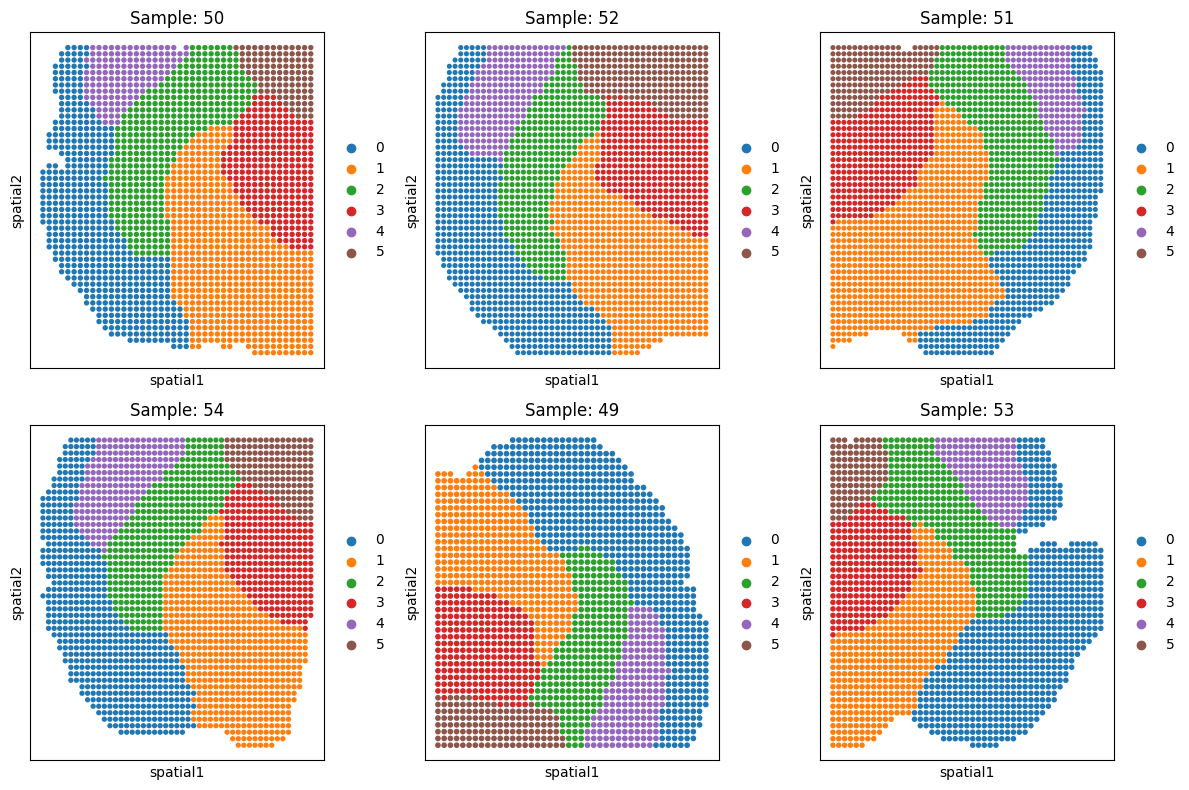

In [8]:
num_samples = len(adata_s)
cols = 3
rows = (num_samples + cols - 1) // cols 
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

# 获取实际的类别数量（防止 n_clusters 对应不上）
# 1. 获取实际的类别数量 (改为 leiden_refined)
# 注意：如果原本标签是字符串，先转为 category 或 str 再处理，防止 astype(int) 报错
unique_labels = sorted(adata.obs["leiden_refined"].unique().astype(str)) 
num_actual_clusters = len(unique_labels)
tmp_colors = sns.color_palette("tab10", num_actual_clusters)
color_palette = {str(lbl): tmp_colors[i] for i, lbl in enumerate(unique_labels)}

for i in range(num_samples):
    ax = axes[i]
    
    # 匹配数据
    cur = adata[adata.obs["batch_name"].astype(str) == str(i)].copy()
    
    if cur.shape[0] > 0:
        if "spatial" not in cur.obsm.keys():
            print(f"❌ 错误：样本 {i} 缺少 spatial 坐标！")
            ax.axis('off')
            continue
            
        # 2. 转换类型用于绘图 (改为 leiden_refined)
        cur.obs["leiden_refined"] = cur.obs["leiden_refined"].astype(str).astype('category')
        
        # 3. 绘图 (改为 leiden_refined)
        sc.pl.embedding(cur, basis="spatial", color="leiden_refined", 
                        palette=color_palette, ax=ax, show=False)
        
        title = sample_names[i] if i < len(sample_names) else f"Batch {i}"
        ax.set_title(f"Sample: {title}")
    else:
        ax.axis('off')

for j in range(num_samples, len(axes)): 
    axes[j].axis('off')

plt.tight_layout()

# 保存
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
save_path = os.path.join(desktop_path, "spCLUE_Final_Plot.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ 图像保存尝试完成: {save_path}")
plt.show()

In [9]:
# 1. 计算邻居 (基于 spCLUE 生成的嵌入空间)
sc.pp.neighbors(adata, use_rep="spCLUE", n_neighbors=15)

# 2. 运行 UMAP 降维
sc.tl.umap(adata)

print("✅ UMAP 坐标计算完成，现在可以对比验证了。")

✅ UMAP 坐标计算完成，现在可以对比验证了。


C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


✅ 验证图已保存至: C:\Users\28616\Desktop\spCLUE_UMAP_Verify.png


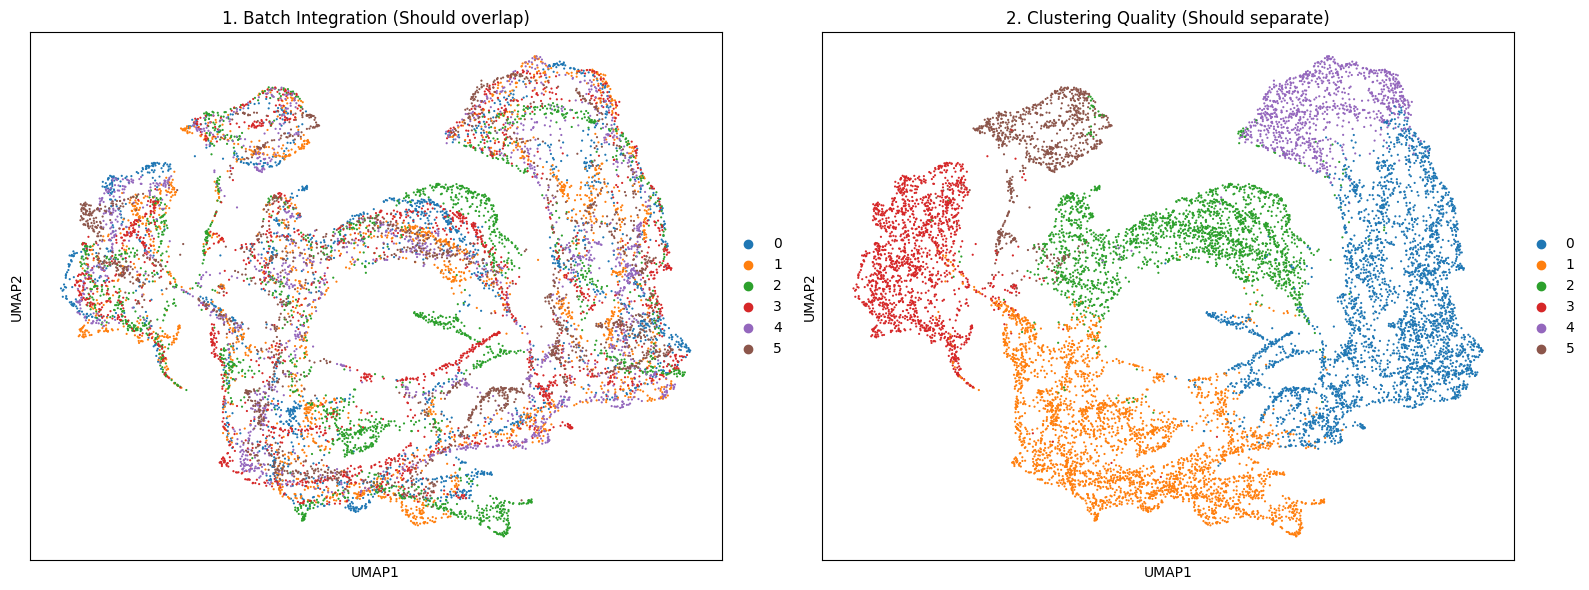

In [10]:
# 设置画布：一横排两个图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 图 1：按批次上色 (Check Batch Integration)
# 如果 6 个样本完全重叠在一起，说明 spCLUE 的批次校正效果很好
sc.pl.umap(adata, color='batch_name', ax=ax1, show=False, title='1. Batch Integration (Should overlap)')

# 图 2：按平滑后的聚类上色 (Check Clustering Consistency)
# 理想状态下，同一种颜色应该聚成一团，且不同颜色之间有明显边界
sc.pl.umap(adata, color='leiden_refined', palette=color_palette, ax=ax2, show=False, title='2. Clustering Quality (Should separate)')

plt.tight_layout()

# 保存验证图到桌面
verify_path = os.path.join(os.path.expanduser("~"), "Desktop", "spCLUE_UMAP_Verify.png")
plt.savefig(verify_path, dpi=300)
print(f"✅ 验证图已保存至: {verify_path}")

plt.show()

🎨 正在使用固定色板并执行空间翻转...


C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\28616\anaconda3\envs\spCLUE\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' wil

✅ 搞定！颜色已同步，翻转已完成：C:\Users\28616\Desktop\spCLUE_Final_Plot_Flipped_leiden.png


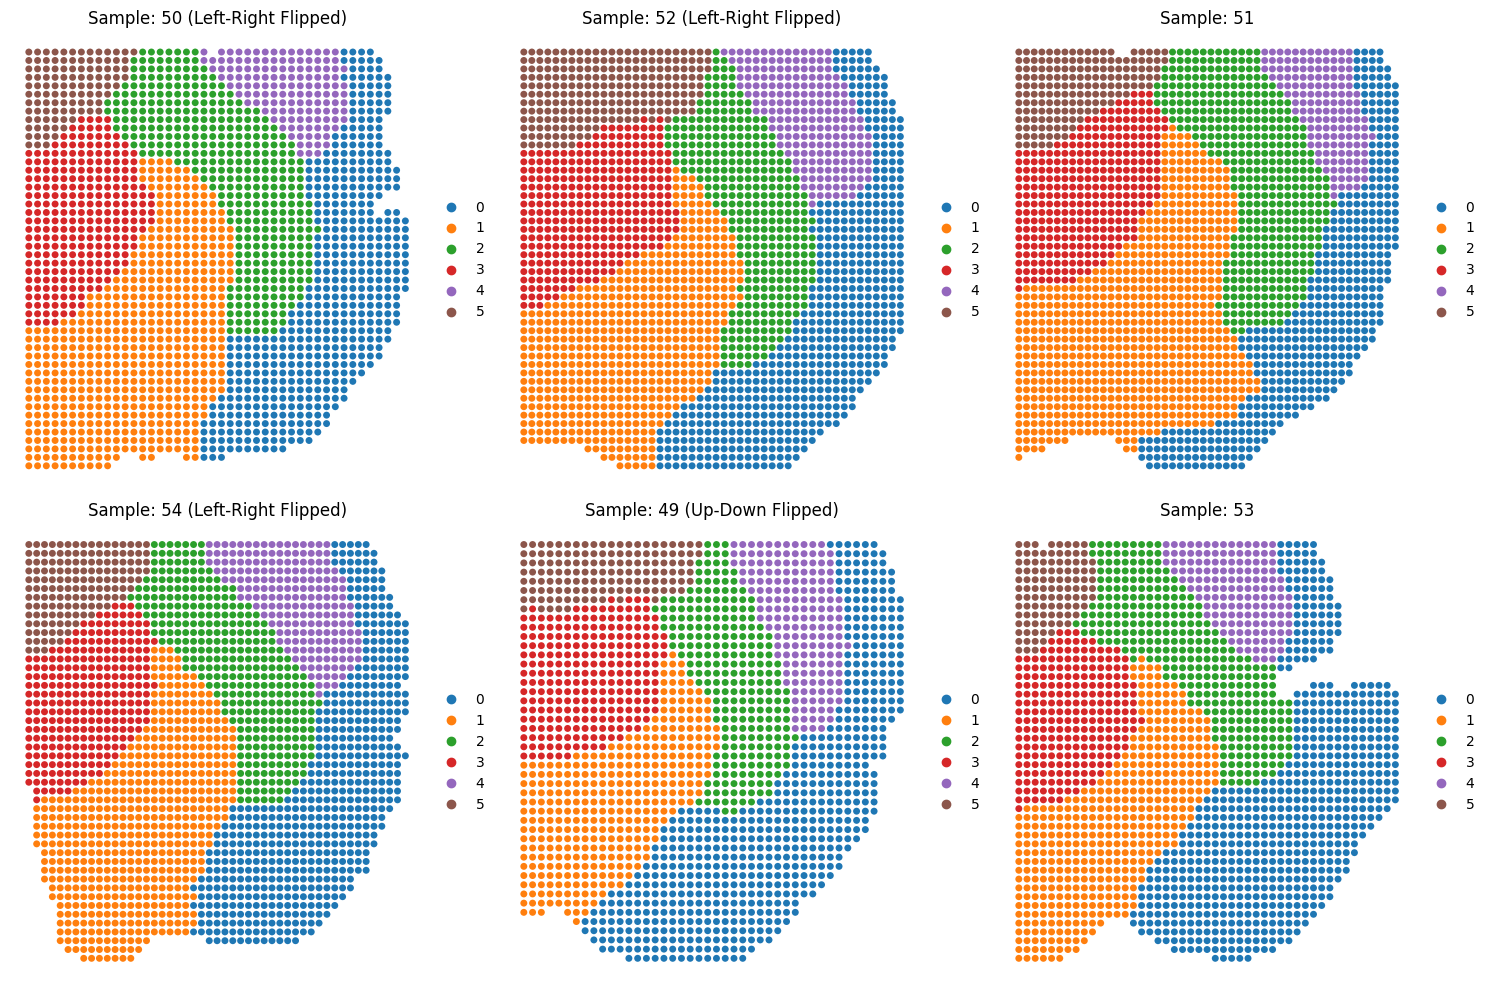

In [11]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors # 引入颜色转换工具
import os

# --- 1. 颜色固定逻辑 (增强版) ---
# 安全提取唯一类别，过滤掉可能的 NaN 值，防止报错
valid_labels = [x for x in adata.obs["leiden_refined"].unique() if pd.notna(x)]
unique_labels_raw = sorted([int(x) for x in valid_labels])
num_actual_clusters = len(unique_labels_raw)

# 使用 tab20 色板 (万一你的聚类数超过10个，tab10会有颜色重复的风险)
tmp_colors = sns.color_palette("tab10", num_actual_clusters)
# 【关键修复】将 RGB tuple 转成 HEX 字符串，确保 Scanpy 100% 能识别
fixed_color_palette = {str(lbl): mcolors.to_hex(tmp_colors[i]) for i, lbl in enumerate(unique_labels_raw)}

# --- 2. 绘图配置 ---
target_order = ["50", "52", "51", "54", "49", "53"]
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
axes = axes.flatten()

print("🎨 正在使用固定色板并执行空间翻转...")

# 【核心修复】放弃容易出错的数学减法，使用直接映射！
# 这里的字典定义了 "你的目标样本名" -> "内存中 batch_name" 的对应关系。
# ⚠️ 注意：如果你之前用了我说的"治本"方法重新读取了数据，你的对应关系应该是这样的：
batch_mapping = {
    "50": "0",
    "52": "1",
    "51": "2",
    "54": "3",
    "49": "4",
    "53": "5"
}
# (如果跑出来全是空白或者不对，说明你没重新读取，那就把字典里的值改回 "49":"0", "50":"1"...)

for i, s_id in enumerate(target_order):
    ax = axes[i]
    
    # 获取正确的 internal_idx
    internal_idx = batch_mapping.get(s_id)
    
    # 提取数据
    cur = adata[adata.obs["batch_name"].astype(str) == internal_idx].copy()
    
    if cur.shape[0] > 0:
        # 复制坐标进行翻转操作
        coords = cur.obsm["spatial"].copy()
        
        # --- 翻转逻辑执行 ---
        flip_info = ""
        if s_id in ["50", "52", "54"]:
            coords[:, 0] = -coords[:, 0]  # X轴反转 = 左右翻转
            flip_info = " (Left-Right Flipped)"
        elif s_id == "49":
            coords[:, 1] = -coords[:, 1]  # Y轴反转 = 上下翻转
            flip_info = " (Up-Down Flipped)"
            
        cur.obsm["spatial"] = coords
        cur.obs["leiden_refined"] = cur.obs["leiden_refined"].astype(str).astype('category')
        
        # 绘图：使用 hex 颜色字典
        sc.pl.embedding(
            cur, 
            basis="spatial", 
            color="leiden_refined", 
            palette=fixed_color_palette, 
            ax=ax, 
            show=False, 
            size=100, 
            frameon=False
        )
        
        ax.set_title(f"Sample: {s_id}{flip_info}")
        ax.set_xlabel(""); ax.set_ylabel("")
    else:
        print(f"⚠️ 找不到样本 {s_id} 的数据，检查映射字典。")
        ax.axis('off')

# 隐藏空白子图
for j in range(len(target_order), len(axes)):
    axes[j].axis('off')

plt.tight_layout()

# --- 3. 保存 ---
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
save_path = os.path.join(desktop_path, "spCLUE_Final_Plot_Flipped_leiden.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ 搞定！颜色已同步，翻转已完成：{save_path}")
plt.show()

In [12]:
import os

output_root = r"C:\Users\28616\Desktop\spCLUE_Results"
os.makedirs(output_root, exist_ok=True)

batch_mapping = {
    "0": "50", "1": "52", "2": "51", "3": "54", "4": "49", "5": "53"
}

print("🚀 开始导出（已加入自动去除后缀逻辑）...")

for internal_idx, s_id in batch_mapping.items():
    sample_mask = adata.obs["batch_name"].astype(str) == internal_idx
    sample_adata = adata[sample_mask]
    
    for n in range(6):
        cluster_mask = sample_adata.obs["leiden_refined"].astype(str) == str(n)
        
        # --- 核心修复：去除后缀 ---
        # 假设 ID 是 bin_10_10_4，我们只取最后一个 "_" 之前的内容
        raw_bins = sample_adata.obs_names[cluster_mask].tolist()
        clean_bins = [b.rsplit('_', 1)[0] for b in raw_bins] 
        
        file_path = os.path.join(output_root, f"{s_id}_cluster{n}.txt")
        with open(file_path, 'w') as f:
            for bin_id in clean_bins:
                f.write(f"{bin_id}\n")
        
        if len(clean_bins) > 0:
            print(f"  ✅ {s_id}_cluster{n}.txt: 已去除后缀并保存 {len(clean_bins)} 个 Bins")

print("\n🎉 修正后的 ID 已全部导出！现在 ID 应该和原始 h5ad 文件完全一致了。")

🚀 开始导出（已加入自动去除后缀逻辑）...
  ✅ 50_cluster0.txt: 已去除后缀并保存 513 个 Bins
  ✅ 50_cluster1.txt: 已去除后缀并保存 572 个 Bins
  ✅ 50_cluster2.txt: 已去除后缀并保存 389 个 Bins
  ✅ 50_cluster3.txt: 已去除后缀并保存 269 个 Bins
  ✅ 50_cluster4.txt: 已去除后缀并保存 138 个 Bins
  ✅ 50_cluster5.txt: 已去除后缀并保存 106 个 Bins
  ✅ 52_cluster0.txt: 已去除后缀并保存 579 个 Bins
  ✅ 52_cluster1.txt: 已去除后缀并保存 561 个 Bins
  ✅ 52_cluster2.txt: 已去除后缀并保存 345 个 Bins
  ✅ 52_cluster3.txt: 已去除后缀并保存 325 个 Bins
  ✅ 52_cluster4.txt: 已去除后缀并保存 208 个 Bins
  ✅ 52_cluster5.txt: 已去除后缀并保存 228 个 Bins
  ✅ 51_cluster0.txt: 已去除后缀并保存 464 个 Bins
  ✅ 51_cluster1.txt: 已去除后缀并保存 727 个 Bins
  ✅ 51_cluster2.txt: 已去除后缀并保存 428 个 Bins
  ✅ 51_cluster3.txt: 已去除后缀并保存 320 个 Bins
  ✅ 51_cluster4.txt: 已去除后缀并保存 149 个 Bins
  ✅ 51_cluster5.txt: 已去除后缀并保存 162 个 Bins
  ✅ 54_cluster0.txt: 已去除后缀并保存 566 个 Bins
  ✅ 54_cluster1.txt: 已去除后缀并保存 550 个 Bins
  ✅ 54_cluster2.txt: 已去除后缀并保存 341 个 Bins
  ✅ 54_cluster3.txt: 已去除后缀并保存 271 个 Bins
  ✅ 54_cluster4.txt: 已去除后缀并保存 201 个 Bins
  ✅ 54_cluster5.txt: 已去除后缀并保存 147 

In [13]:
import os
import scanpy as sc

# 1. 路径和配置
h5ad_dir = r"C:\Users\28616\Desktop\spatialDE_rawdata\ATOI"
output_dir = r"C:\Users\28616\Desktop\spCLUE_Results"

print("--- 开始彻底清理后缀并导出 ---")

# 2. 遍历每一个 cluster
for cluster_id in range(9):
    # 筛选出属于当前 cluster 的所有 cell (使用合并后的 adata 来获取聚类归属)
    cluster_mask = adata.obs["leiden_refined"].astype(int) == cluster_id
    cluster_data = adata[cluster_mask]
    
    # 3. 遍历每一个 batch (0-5)
    for internal_idx in range(6):
        sample_mask = cluster_data.obs["batch_name"].astype(str) == str(internal_idx)
        cluster_sample_data = cluster_data[sample_mask]
        
        # 【关键修复】：这里提取名称时，直接从原始路径获取，或者直接清洗
        # 我们在这里通过 str.split('_')[0] 强行去掉所有下划线及其后面的后缀
        # 假设原始 ID 格式是 'bin_x_y'，而 concat 后变成了 'bin_x_y_0'
        clean_bin_names = [name.rsplit('_', 1)[0] for name in cluster_sample_data.obs_names]
        
        # 4. 保存
        sample_id = str(internal_idx + 49)
        file_path = os.path.join(output_dir, f"{sample_id}_cluster{cluster_id}.txt")
        
        with open(file_path, 'w') as f:
            for name in clean_bin_names:
                f.write(f"{name}\n")
    
    print(f"Cluster {cluster_id} 处理完毕")

print("✅ 所有 txt 已清理干净，后缀已彻底移除。")

--- 开始彻底清理后缀并导出 ---
Cluster 0 处理完毕
Cluster 1 处理完毕
Cluster 2 处理完毕
Cluster 3 处理完毕
Cluster 4 处理完毕
Cluster 5 处理完毕
Cluster 6 处理完毕
Cluster 7 处理完毕
Cluster 8 处理完毕
✅ 所有 txt 已清理干净，后缀已彻底移除。
